In [1]:
pip install --upgrade keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install jax jaxlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt


In [6]:
pip install tensorflow-datasets


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.decomposition import PCA

In [8]:
import keras as tf
import keras
model = keras.Sequential()

# -----------------------
# Data 
# -----------------------
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

In [9]:
x_train_img.dtype, y_train.dtype, x_test_img.dtype, y_test.dtype

(dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'))

In [10]:
# Normalize images in [0,1]
x_train_img = x_train_img.astype(np.float32) / 255.0   # (N,28,28)
x_test_img  = x_test_img.astype(np.float32)  / 255.0

y_train = y_train.astype(np.int64)
y_test  = y_test.astype(np.int64)

In [11]:
# Flattened versions for NumPy training
x_train = x_train_img.reshape(-1, 784)  # (N,784)
x_test  = x_test_img.reshape(-1, 784)



In the below section, I'm focusing on data exploratory analysis where I'll try to understand the data.

In the below boxplot, I've focused on mean intensity of each digits. Outliers represents the dark images.

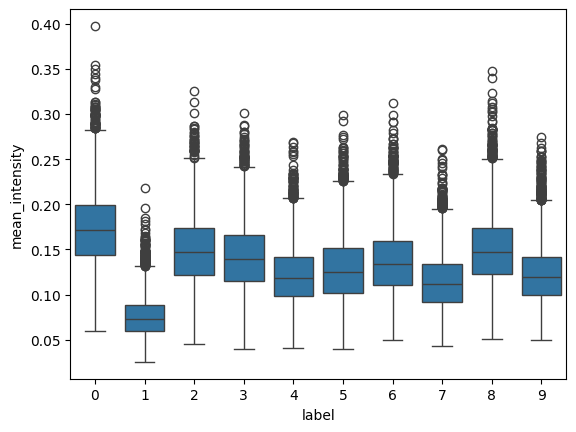

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Outliers per digits:
df = pd.DataFrame({
    'mean_intensity': x_train.mean(axis=1),
    'label': y_train
})

sns.boxplot(data=df, x='label', y='mean_intensity')
plt.show()

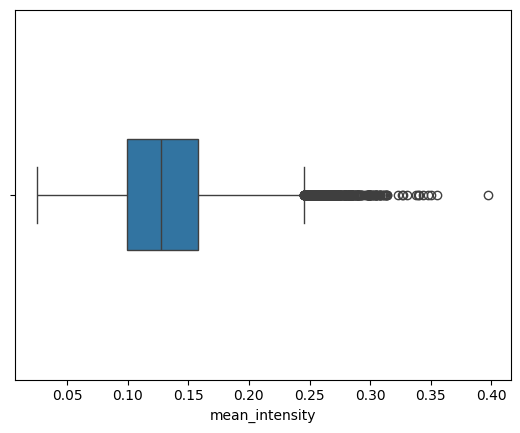

In [13]:
#Check the outliers from the training set using boxplot
# Compute mean pixel value per image
#very dark images (possible outliers)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute mean pixel value per image
mean_intensity = x_train.mean(axis=1)  # shape (N,)

df = pd.DataFrame({'mean_intensity': mean_intensity})

sns.boxplot(data=df, x='mean_intensity', width=0.3)
plt.show()

In [14]:
for column in df.select_dtypes(include=np.number).columns:
    q25 = df[column].quantile(0.25)
    q75 = df[column].quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {outliers.shape[0]} outliers")

mean_intensity: 610 outliers


In [15]:
df.columns

Index(['mean_intensity'], dtype='object')

In [16]:
#count missing values in the dataset
#keras does not have missing values in the dataset, but we can check for missing values in the dataframe
missing_values = df.isnull().sum()
print(f"Missing values:\n{missing_values}")

Missing values:
mean_intensity    0
dtype: int64


In [17]:
pca = PCA(n_components=1)
pc1 = pca.fit_transform(x_train)

df = pd.DataFrame({'PC1': pc1[:, 0]})

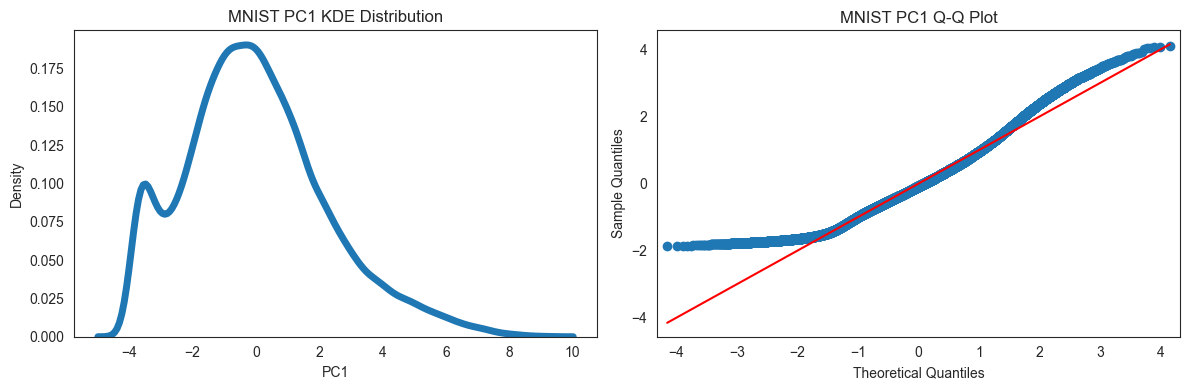

In [18]:
sns.set_style("white")

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

# KDE plot
sns.kdeplot(data=df, x="PC1", linewidth=5, ax=ax1)
ax1.set_title("MNIST PC1 KDE Distribution")

# Q-Q plot
sm.qqplot(df['PC1'], line='s', ax=ax2, dist=stats.norm, fit=True)
ax2.set_title("MNIST PC1 Q-Q Plot")

plt.tight_layout()
plt.show()

In [19]:
# -----------------------
# Data 
# -----------------------
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()
# Normalize images in [0,1]
x_train_img = x_train_img.astype(np.float32) / 255.0   # (N,28,28)
x_test_img  = x_test_img.astype(np.float32)  / 255.0

y_train = y_train.astype(np.int64)
y_test  = y_test.astype(np.int64)
# Flattened versions for NumPy training
x_train = x_train_img.reshape(-1, 784)  # (N,784)
x_test  = x_test_img.reshape(-1, 784)

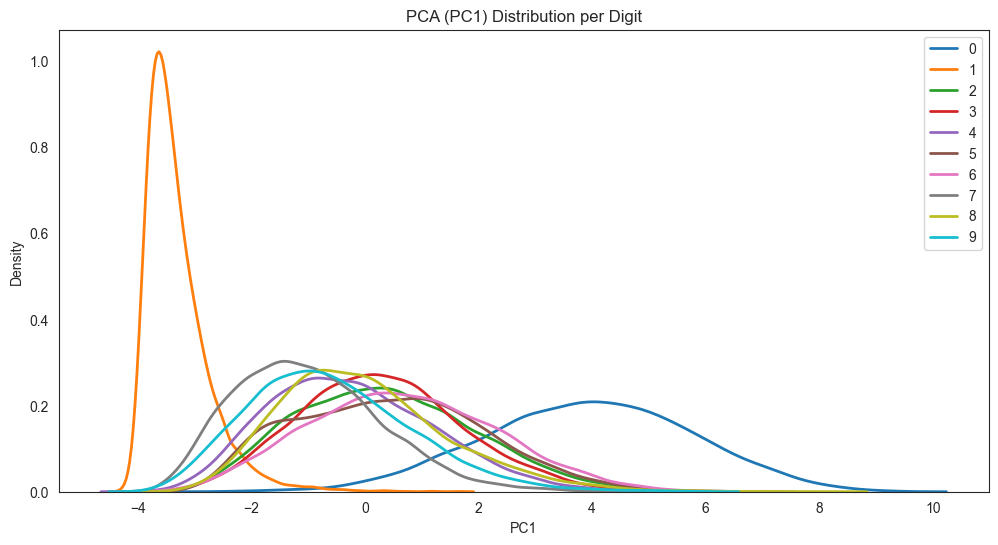

In [20]:
# PCA and KDE plot per digit: we're checking the distribution of the first principal component (PC1) for each digit class to see if there are
#  any differences in the distributions across the classes. This can help us understand if PCA is capturing meaningful variance 
# related to the digit classes.
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=1)
pc1 = pca.fit_transform(x_train)

df = pd.DataFrame({
    'PC1': pc1[:, 0],
    'label': y_train
})

sns.set_style("white")

plt.figure(figsize=(12,6))

for digit in range(10):
    sns.kdeplot(
        data=df[df['label'] == digit],
        x='PC1',
        label=str(digit),
        linewidth=2
    )

plt.title("PCA (PC1) Distribution per Digit")
plt.legend()
plt.show()

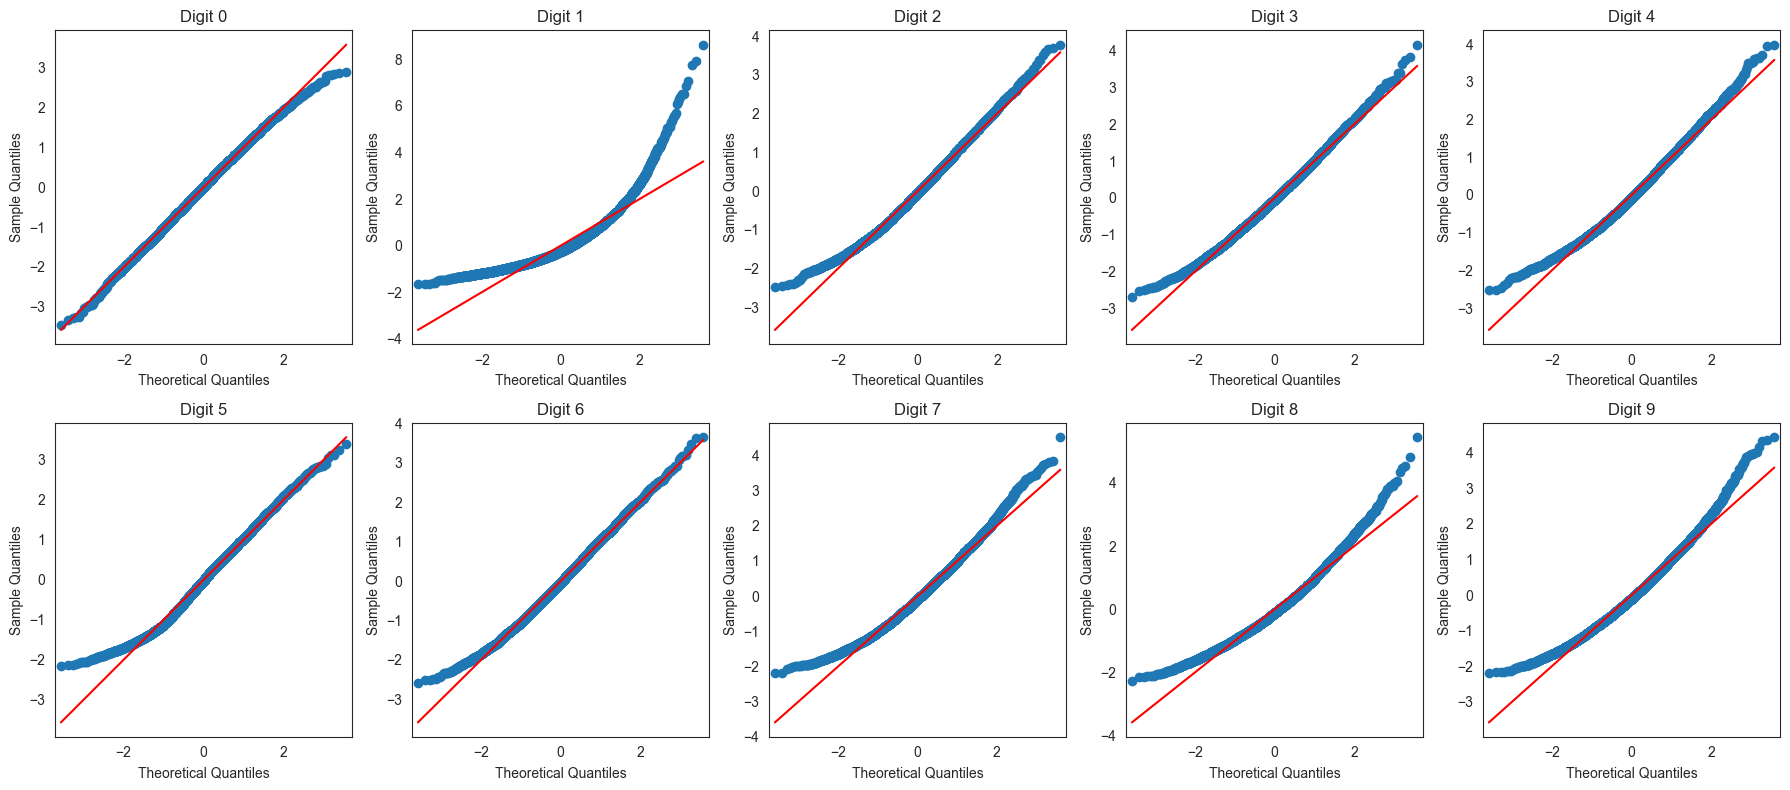

In [21]:
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.ravel()

for digit in range(10):
    sm.qqplot(
        df[df['label'] == digit]['PC1'],
        line='s',
        ax=axes[digit],
        dist=stats.norm,
        fit=True
    )
    axes[digit].set_title(f"Digit {digit}")

plt.tight_layout()
plt.show()

None of the digits are evenly distributed.
MNIST is manifold-structured data
Not generated from Gaussian processes
Each digit class has its own latent distribution

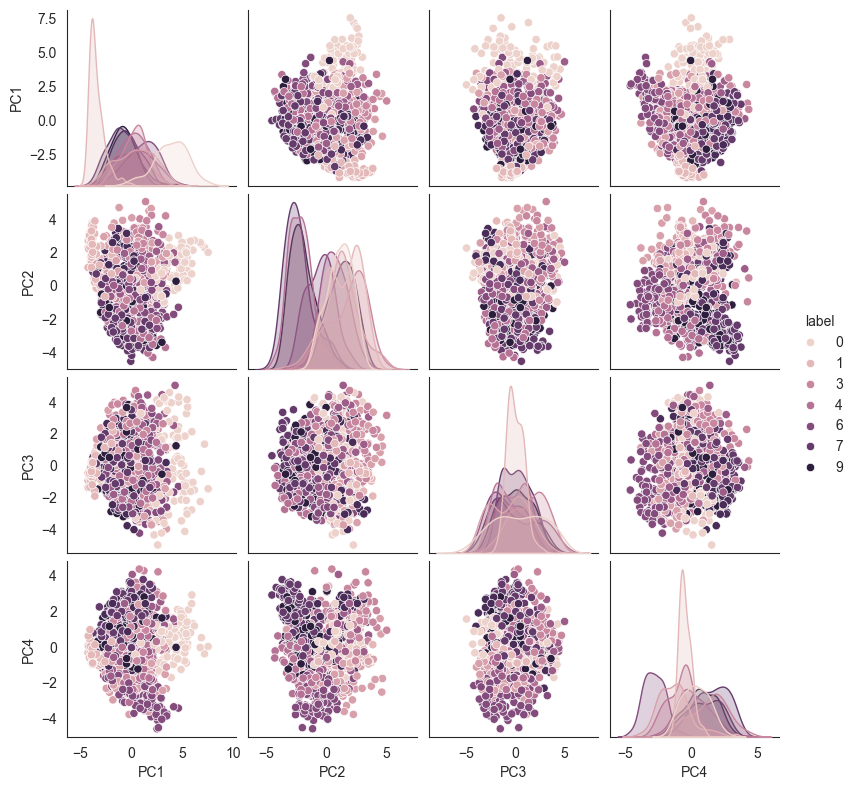

In [22]:
#generate pair plot of the first 10 images in the training set
# Use PCA to reduce dimensionality to 4 features, then create a pairplot colored by labels
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Take a smaller subset (important for speed)
X_subset = x_train[:1000]
y_subset = y_train[:1000]

# Apply PCA → reduce 784 → 4 features
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_subset)

# Create DataFrame
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df['label'] = y_subset

# Pairplot
sns.pairplot(df, hue='label', height=2)
plt.show()

In [23]:
# print shapes of training and test here
print(f"Training data shape: {x_train_img.shape}")
print(f"Test data shape: {x_test_img.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Unique Labels:{np.unique(y_test)}")
print(f"Unique Labels:{np.unique(y_train)}")
print(f"Number of unique data points: {len(np.unique(x_train_img))}")
print(f"Number of unique data points: {len(np.unique(x_test_img))}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)
Unique Labels:[0 1 2 3 4 5 6 7 8 9]
Unique Labels:[0 1 2 3 4 5 6 7 8 9]
Number of unique data points: 256
Number of unique data points: 256


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, precision_recall_fscore_support)

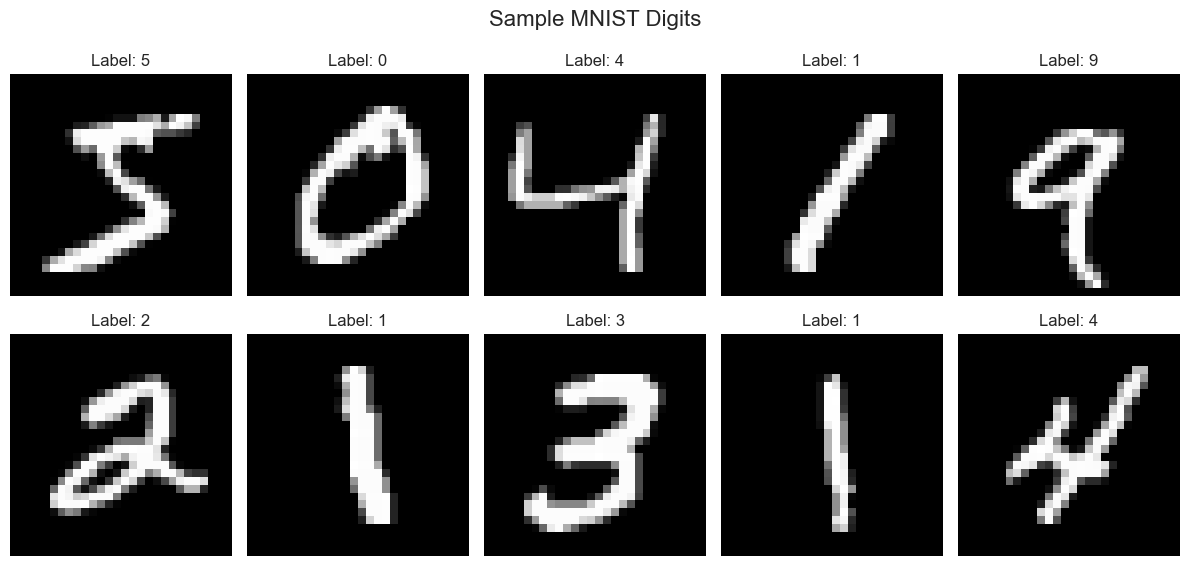

In [25]:
def visualize_samples(x_train_img, y_train, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Sample MNIST Digits', fontsize=16)
    for i in range(num_samples):
        row = i // 5
        col = i % 5
         # Reshape the flattened image back to 28x28
        digit_image = x_train_img[i].reshape(28,28)
        axes[row, col].imshow(digit_image, cmap='gray')
        axes[row, col].set_title(f'Label: {y_train[i]}')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
# Load the data
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()
# Visualize some samples
visualize_samples(x_train_img,y_train)

In [26]:
pip install pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


In [27]:
#check for null values
print("Checking for null values in training data:")
print(f"Null values in X_train: {np.isnan(x_train_img).sum()}")
print(f"Null values in y_train: {np.isnan(y_train).sum()}") 

Checking for null values in training data:
Null values in X_train: 0
Null values in y_train: 0


In [28]:
def get_classifiers():
    """
    Define all classification algorithms to compare
    
    Returns:
        Dictionary of classifier name and instance
    """
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Support Vector Machine': SVC(kernel='rbf', random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': GaussianNB(),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
        'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(100, 50), 
                                            max_iter=500, random_state=42)
    }
    
    return classifiers

In [29]:
#implementing the HOG feature extraction for the MNIST dataset
from skimage.feature import hog
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# 1. Load and Normalize Data
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0, 1]
x_train_img = x_train_img.astype('float32') / 255.0
x_test_img = x_test_img.astype('float32') / 255.0

# (Optional) Subset the data for speed - remove these lines to use full dataset
x_train_img, y_train = x_train_img[:10000], y_train[:10000]
x_test_img, y_test = x_test_img[:2000], y_test[:2000]

Offline vs Online Data Augmentation

Augmentation can happen before training or during training. Offline augmentation expands the dataset once and saves it. Online augmentation generates new variations every epoch. Deep learning pipelines usually prefer online augmentation because it exposes the model to effectively unbounded variation without increasing storage.

Data Augmentation for Image Data

Image data augmentation is the most intuitive place to start. A dog is still a dog if it’s slightly rotated, zoomed, or viewed under different lighting conditions. Your model needs to see these variations during training. Some common image augmentation techniques are:

    Rotation
    Flipping
    Resizing
    Cropping
    Zooming
    Shifting
    Shearing
    Brightness and contrast changes

These transformations do not change the label—only the appearance. Let’s demonstrate with a simple example using TensorFlow and Keras:

Reshaped training data: (10000, 28, 28, 1)
Reshaped test data: (2000, 28, 28, 1)
Augmented data shape: (10000, 28, 28)
Augmented labels shape: (10000,)
Combined training data shape: (20000, 28, 28)
Combined training labels shape: (20000,)
One-hot encoded training labels shape: (20000, 10)
One-hot encoded test labels shape: (2000, 10)


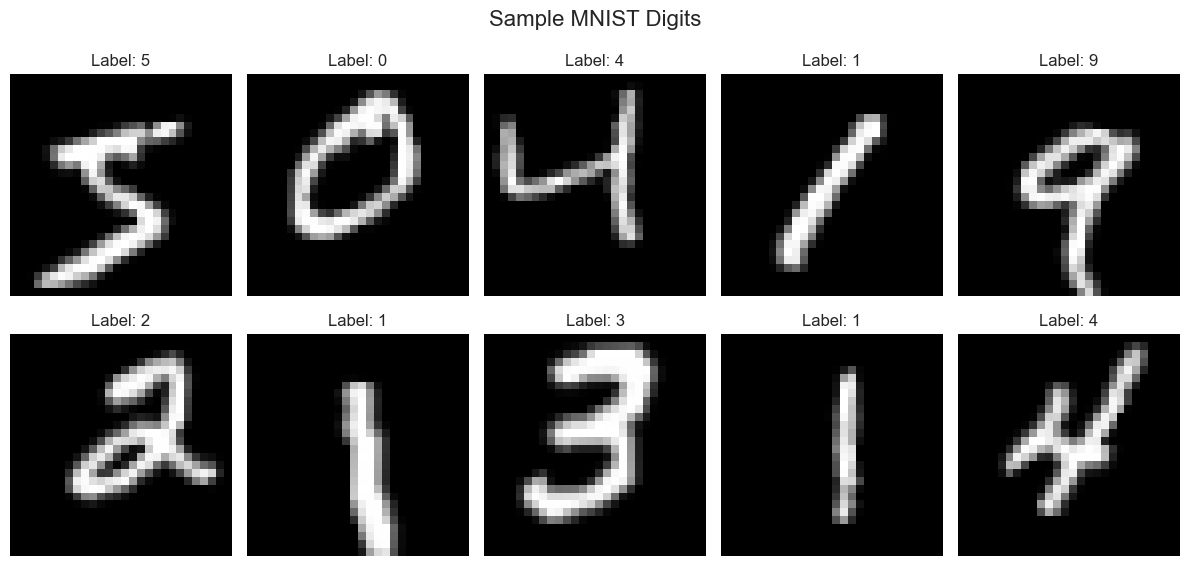

In [31]:
# --- 2. Image Augmentation ---
# Reshape for the generator (N, 28, 28, 1)
x_train_reshaped = x_train_img.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_img.reshape(-1, 28, 28, 1)
print(f"Reshaped training data: {x_train_reshaped.shape}")
print(f"Reshaped test data: {x_test_reshaped.shape}")



datagen = ImageDataGenerator(
    rotation_range=12,      # Small rotation for digits
    width_shift_range=0.1,  # Horizontal translation
    height_shift_range=0.1, # Vertical translation
    zoom_range=0.1,      
    shear_range=0.1,   
    horizontal_flip=False,  # Horizontal flip doesn't make sense for digits '9' and '6'
    fill_mode='constant',
    cval=0
)

aug_x, aug_y = [], []
for i in range(len(x_train_reshaped)):
    img = x_train_reshaped[i].reshape((1, 28, 28, 1))
    # Generate one augmented version
    for batch in datagen.flow(img, batch_size=1):
        aug_x.append(batch[0].reshape(28, 28))
        aug_y.append(y_train[i])
        break  # Stop after one augmentation per image
aug_x = np.array(aug_x)
aug_y = np.array(aug_y)
print(f"Augmented data shape: {aug_x.shape}")
print(f"Augmented labels shape: {aug_y.shape}")

# Combine original with augmented
x_train_combined = np.concatenate([x_train_img, np.array(aug_x)])
y_train_combined = np.concatenate([y_train, np.array(aug_y)])

print(f"Combined training data shape: {x_train_combined.shape}")
print(f"Combined training labels shape: {y_train_combined.shape}")

# --- 3. One-Hot Encoding ---
# Crucial for Cross-Entropy loss in Gradient Descent
y_train_encoded = to_categorical(y_train_combined, 10)
y_test_encoded = to_categorical(y_test, 10)
print(f"One-hot encoded training labels shape: {y_train_encoded.shape}")
print(f"One-hot encoded test labels shape: {y_test_encoded.shape}")

# Visualize some samples
visualize_samples(np.array(aug_x), np.array(aug_y))


. Why HOG is better than Raw Pixels

Raw pixels are "brittle." If you shift a digit just 2 pixels to the left, every single pixel value in your 784-dimensional vector changes, even though the shape is the same. This makes it very hard for a model to generalize.

HOG (Histogram of Oriented Gradients) fixes this by focusing on structure:

    Gradient Directions: Instead of looking at "is this pixel white?", HOG asks "which way is the edge pointing?"

    Spatial Invariance: It groups pixels into small cells. As long as the "top curve" of a 2 is roughly in the same area, the HOG feature remains stable even if the digit is slightly tilted or shifted.

2. Why SVM is the Perfect Partner

An SVM doesn't just try to classify data; it tries to find the Maximum Margin Hyperplane.

In a high-dimensional space (like the one created by HOG), an SVM looks for the widest possible "street" between classes (e.g., separating the 1s from the 7s).
The "Soft Margin" (C)

In real-world data like MNIST, some people write their 4s so messily they look like 9s. A "Hard Margin" SVM would fail because it tries to perfectly separate every single point.

    The Soft Margin introduces "slack variables" (ξ).

    It allows the model to "ignore" a few outliers or misclassified points in exchange for a much cleaner, more robust boundary for the rest of the data.

The optimization problem looks like this:
w,b,ξmin​21​∥w∥2+Ci=1∑n​ξi​
3. The Synergy: Feature Space vs. Classifier

The reason they work so well together is Linear Separability:

    HOG transforms the "messy" raw pixel space into a "structured" feature space.

    In this new space, the different digits are much more likely to be linearly separable (or close to it).

    SVM is mathematically the most powerful tool for finding that linear boundary.



In [32]:



def hog_feature_extraction(imgs):
    """
    Extract HOG features from the input images
    
    Args:
        X: Input images (N, 28, 28)
    
    Returns:
        features: Extracted HOG features (N, 324)
    """
    features = []
    for img in imgs:
        hog_features = hog(img, orientations=9, pixels_per_cell=(5, 5), cells_per_block=(2, 2), visualize=False)
        features.append(hog_features)
    return np.array(features)

print("Extracting HOG features from augmented dataset...")
x_train_hog = hog_feature_extraction(x_train_combined)
# Note: We do NOT augment test data. We only extract HOG features from it.
x_test_hog = hog_feature_extraction(x_test_img)
print(f"New feature vector shape: {x_train_hog.shape[1]}")



Extracting HOG features from augmented dataset...
New feature vector shape: 576


You must fit the scaler on the Training Data only and then apply that same transformation to the Test Data to avoid "data leakage."
To standardize your HOG features for fast Gradient Descent performance, you should use Z-score Standardization. This ensures that the 324 features are centered at zero and scaled to unit variance, which prevents "wide" features from dominating the gradient updates and allows for a higher learning rate.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit on training data, transform both
x_train_hog_scaled = scaler.fit_transform(x_train_hog)
x_test_hog_scaled = scaler.transform(x_test_hog)

print(f"Mean after standardization: {np.mean(x_train_hog_scaled):.2f}")
print(f"Std after standardization: {np.std(x_train_hog_scaled):.2f}")


Mean after standardization: -0.00
Std after standardization: 1.00


Adding the Bias Term (Crucial for Accuracy)

Standardization centers your data, but for the mathematical equation y=Wx+b to work efficiently in a vectorized format, you should append a "column of ones" to your feature matrix. This allows the bias b to be learned as just another weight.

In [34]:
# Add a column of 1s to the end of the 324 features
x_train_final = np.hstack([x_train_hog_scaled, np.ones((x_train_hog_scaled.shape[0], 1))])
x_test_final = np.hstack([x_test_hog_scaled, np.ones((x_test_hog_scaled.shape[0], 1))])

print(f"Final Input Shape: {x_train_final.shape}") # (N, 325)

Final Input Shape: (20000, 577)


In [35]:
print(x_train_final.shape)
print(x_test_final.shape)

(20000, 577)
(2000, 577)


In [ ]:
rmse=[]   

# C is the penalty parameter. Lower C = softer margin (more regularization)
svm_model = LinearSVC(C=1, loss='hinge', dual='auto', max_iter=10000)
svm_model.fit(x_train_final, y_train_combined)
#implement rbf kernel SVM
rbf_svm_model = SVC(kernel='rbf', C=1, gamma='scale')
rbf_svm_model.fit(x_train_final, y_train_combined)


#Evaluate SVM
svm_pred = svm_model.predict(x_test_final)
rbf_pred = rbf_svm_model.predict(x_test_final)
rmse.append(mean_squared_error(y_test, svm_pred))
rmse.append(mean_squared_error(y_test, rbf_pred))
print(f"SVM Accuracy (HOG): {accuracy_score(y_test, svm_pred):.4f}")
print(f"RBF SVM Accuracy (HOG): {accuracy_score(y_test, rbf_pred):.4f}")
print("Classification Report for Linear SVM:")
print(classification_report(y_test, svm_pred))
print("Mean Squared Error for Linear SVM:", mean_squared_error(y_test, svm_pred))
print("Classification Report for RBF SVM:")
print(classification_report(y_test, rbf_pred))      
print("Mean Squared Error for RBF SVM:", mean_squared_error(y_test, rbf_pred))



In [ ]:
cm_svm = confusion_matrix(y_test, svm_pred)
cm_rbf = confusion_matrix(y_test, rbf_pred)

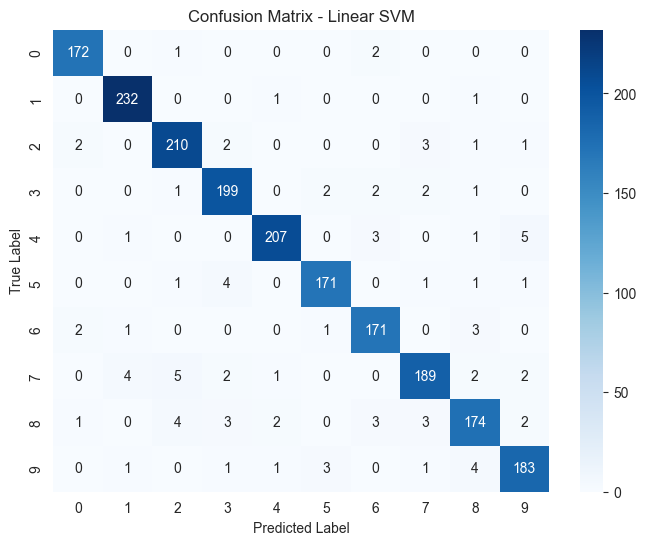

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

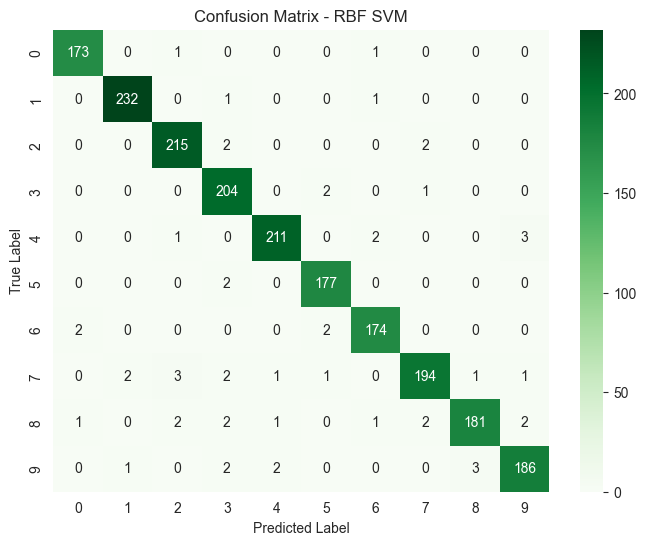

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
#implementing logistic regression with HOG features
rmse =[]
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', multi_class='multinomial')
log_reg_model.fit(x_train_final, y_train_combined)

#Evaluate Logistic Regression
log_reg_pred = log_reg_model.predict(x_test_final)
print(f"Logistic Regression Accuracy (HOG): {accuracy_score(y_test, log_reg_pred):.4f}")
print("Classification Report for Logistic Regression:") 
print(classification_report(y_test, log_reg_pred))
print("Mean Squared Error for Logistic Regression:", mean_squared_error(y_test, log_reg_pred))
rmse.append(mean_squared_error(y_test, log_reg_pred))
print("RMSE values for all models:", rmse)


C:\Users\yashs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy (HOG): 0.9525
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       175
           1       0.97      0.99      0.98       234
           2       0.93      0.95      0.94       219
           3       0.92      0.97      0.94       207
           4       0.96      0.96      0.96       217
           5       0.96      0.96      0.96       179
           6       0.97      0.97      0.97       178
           7       0.96      0.91      0.94       205
           8       0.92      0.91      0.92       192
           9       0.96      0.92      0.94       194

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000

Mean Squared Error for Logistic Regression: 0.763
RMSE values for all models: [0.763]


In [ ]:
cm_log_reg = confusion_matrix(y_test, log_reg_pred)

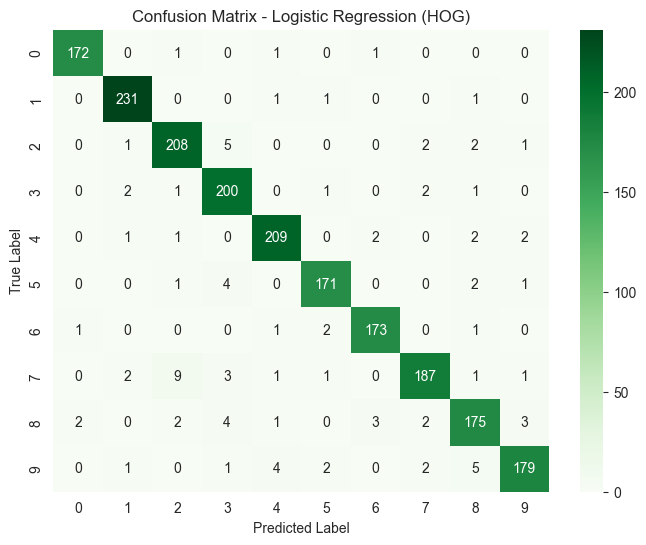

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Logistic Regression (HOG)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
#one-hot
#def one_hot(y, num_classes=10):
#    Y = np.zeros((len(y), num_classes))
#    Y[np.arange(len(y)), y] = 1
#    return Y


#Y_train = one_hot(y_train_combined)
#Y_test = one_hot(y_test)

from tensorflow.keras.utils import to_categorical
Y_train = to_categorical(y_train_combined, 10)
Y_test = to_categorical(y_test, 10) 
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")
print(f"X_train shape: {x_train_final.shape}")
print(f"X_test shape: {x_test_final.shape}")

Y_train shape: (20000, 10)
Y_test shape: (2000, 10)
X_train shape: (20000, 577)
X_test shape: (2000, 577)


In [ ]:


import matplotlib.pyplot as plt
import keras
from keras import layers
import numpy as np

# 1. Setup labels and parameters
Y_train_int = np.argmax(Y_train, axis=1)
Y_test_int = np.argmax(Y_test, axis=1)
num_features = x_train_final.shape[1]
print(f"Number of features: {num_features}")
print(f"Unique labels in training set: {np.unique(Y_train_int)}")
print(f"Unique labels in test set: {np.unique(Y_test_int)}")
def train_model(activation):
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(
    128, 
    activation=activation,
    kernel_initializer='he_uniform',
    bias_initializer='zeros'
),
layers.Dense(
    64, 
    activation=activation,
    kernel_initializer='he_uniform',
    bias_initializer='zeros'
),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        x_train_final, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )
    
    test_loss, test_acc = model.evaluate(x_test_final, Y_test_int, verbose=0)
    
    return history, test_acc, test_loss


Number of features: 577
Unique labels in training set: [0 1 2 3 4 5 6 7 8 9]
Unique labels in test set: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
history_relu, acc_relu, loss_relu = train_model('relu')
history_sigmoid, acc_sigmoid, loss_sigmoid = train_model('sigmoid')
history_tanh, acc_tanh, loss_tanh = train_model('tanh')
print(f"ReLU Test Accuracy: {acc_relu:.4f}, Test Loss: {loss_relu:.4f}")
print(f"Sigmoid Test Accuracy: {acc_sigmoid:.4f}, Test Loss: {loss_sigmoid:.4f}")
print(f"Tanh Test Accuracy: {acc_tanh:.4f}, Test Loss: {loss_tanh:.4f}")

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9002 - loss: 0.3214 - val_accuracy: 0.9025 - val_loss: 0.2847
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.0936 - val_accuracy: 0.9145 - val_loss: 0.2780
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9842 - loss: 0.0483 - val_accuracy: 0.9210 - val_loss: 0.2489
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9920 - loss: 0.0269 - val_accuracy: 0.9260 - val_loss: 0.2774
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0252 - val_accuracy: 0.9350 - val_loss: 0.2733
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9918 - loss: 0.0238 - val_accuracy: 0.9160 - val_loss: 0.3523
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9255 - val_loss: 0.3084
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9932 - loss: 0.0209 - val_accuracy: 0.

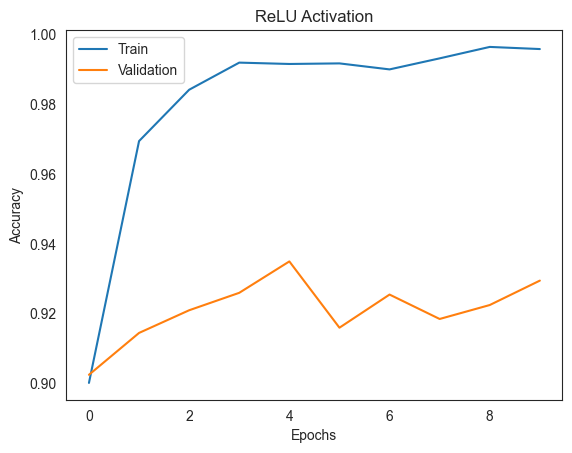

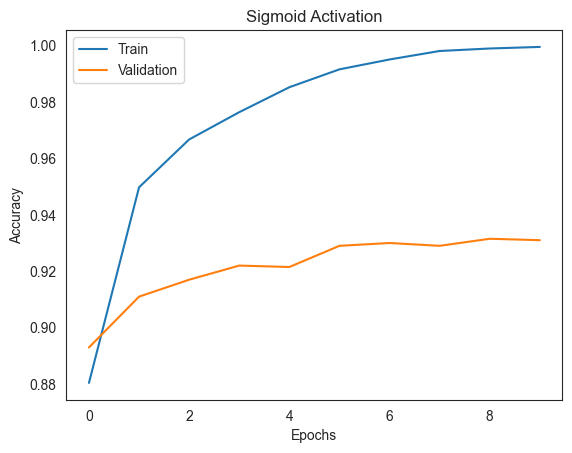

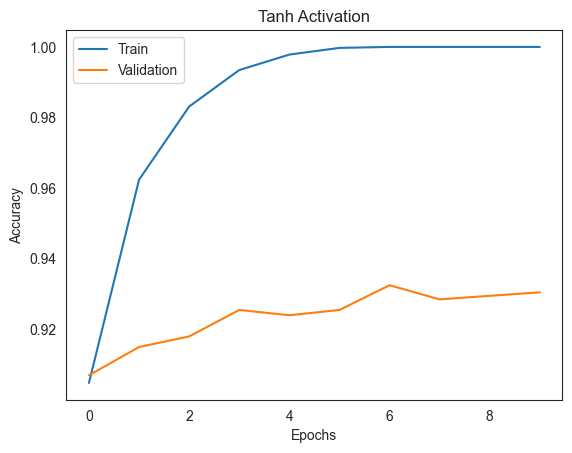

In [ ]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
plot_history(history_relu, "ReLU Activation")
plot_history(history_sigmoid, "Sigmoid Activation") 
plot_history(history_tanh, "Tanh Activation")

In [ ]:
print("ReLU    -> Acc:", acc_relu, "Loss:", loss_relu)
print("Sigmoid -> Acc:", acc_sigmoid, "Loss:", loss_sigmoid)
print("Tanh    -> Acc:", acc_tanh, "Loss:", loss_tanh)


ReLU    -> Acc: 0.9589999914169312 Loss: 0.20074132084846497
Sigmoid -> Acc: 0.9649999737739563 Loss: 0.11321357637643814
Tanh    -> Acc: 0.968999981880188 Loss: 0.11942566931247711


In [ ]:
#clean comparison with keras optimizers

optimizers = {
    "GD": keras.optimizers.SGD(learning_rate=0.01),
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "AGD": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
}

results = {}

for name, optimizer in optimizers.items():
    
    print(f"\nTraining with {name}")
    
    model = keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(64, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Batch size difference
    if name == "GD":
        batch_size = len(x_train_final)
    else:
        batch_size = 32
    
    history = model.fit(
        x_train_final,
        np.argmax(Y_train, axis=1),
        epochs=10,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(
        x_test_final,
        np.argmax(Y_test, axis=1),
        verbose=0
    )

    
    results[name] = {
        "history": history.history,
        "test_acc": test_acc}

    print(f"{name} Accuracy: {test_acc:.4f}")





Training with GD
GD Accuracy: 0.2200

Training with SGD
SGD Accuracy: 0.9575

Training with AGD
AGD Accuracy: 0.9695


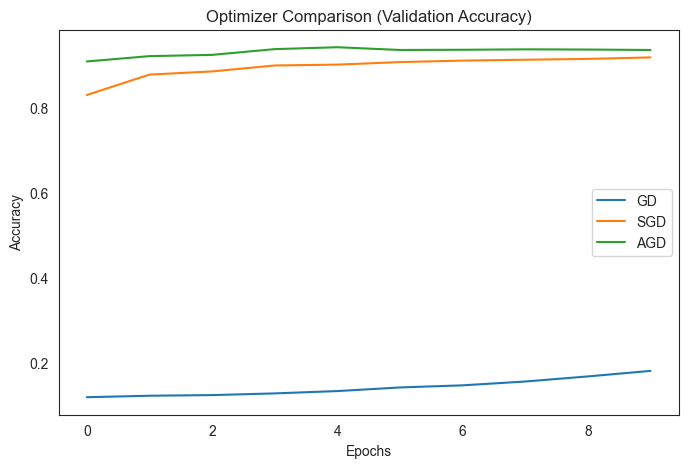

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name in results:
    plt.plot(results[name]['history']['val_accuracy'], label=name)

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
#Adding L1-norm and L2-norm regularizations and compare the training and testing performance.

from keras import regularizers

#L1 Regularization
def create_model_l1():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        
        layers.Dense(128, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l1(1e-4)),
        
        layers.Dense(64, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l1(1e-4)),
        
        layers.Dense(10, activation='softmax')
    ])

#L2 Regularization
def create_model_l2():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        
        layers.Dense(128, activation='relu',
                     kernel_initializer='he_uniform',   
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(64, activation='relu',
                        kernel_initializer='he_uniform',
                        kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dense(10, activation='softmax')
    ])

#no regularization
def create_model_base():
    return keras.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(64, activation='relu', kernel_initializer='he_uniform'),
        layers.Dense(10, activation='softmax')
    ])
models = {
    "No Reg": create_model_base(),
    "L1": create_model_l1(),
    "L2": create_model_l2()
}

results_reg = {}

for name, model in models.items():
    print(f"\nTraining with {name}")
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        x_train_final,
        np.argmax(Y_train, axis=1),
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(
        x_test_final,
        np.argmax(Y_test, axis=1),
        verbose=0
    )
    
    results_reg[name] = {
        "history": history.history,
        "test_acc": test_acc
    }
    
    print(f"{name} Test Accuracy: {test_acc:.4f}")
    print(f"{name} Test Loss: {test_loss:.4f}")




Training with No Reg
No Reg Test Accuracy: 0.9590
No Reg Test Loss: 0.1853

Training with L1
L1 Test Accuracy: 0.9590
L1 Test Loss: 0.3289

Training with L2
L2 Test Accuracy: 0.9565
L2 Test Loss: 0.2459


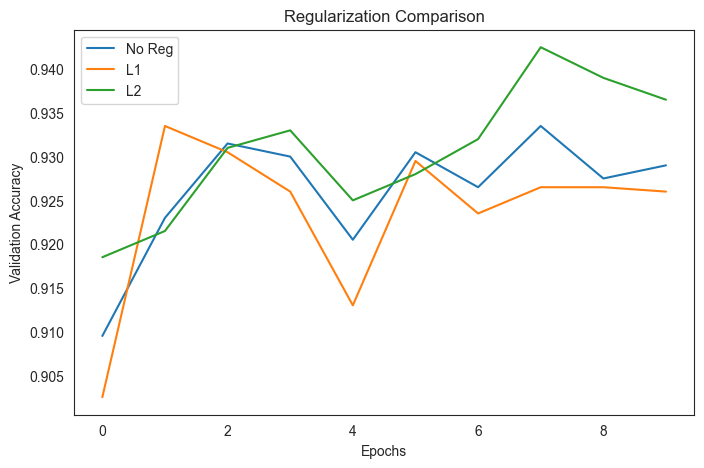

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for name in results_reg:
    plt.plot(results_reg[name]['history']['val_accuracy'], label=name)

plt.title("Regularization Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import numpy.linalg as la

def gd_onedot(X, Y, W0, epsilon=1e-6, max_iter=500):
    """
    Gradient Descent for min ||XW - Y||^2
    X: (m, n)
    Y: (m, k)  -> one-hot labels
    W0: (n, k) initial weights
    """
    
    W = W0.copy()
    
    # initial gradient
    grad = 2 * X.T @ (X @ W - Y)
    grad_norms = []
    print(f"Initial ||grad||: {la.norm(grad):.4e}")
    grad_norm = la.norm(grad)
    losses = []
    
    iter_count = 0
      # Lipschitz constant
    L = 2 * la.norm(X, 2)**2
    alpha = 2 / L  # Step size based on Lipschitz constant
    while la.norm(grad) > epsilon and iter_count < max_iter:
        
      
        
        # gradient update
        W = W - alpha * grad
        
        # recompute gradient
        grad = 2 * X.T @ (X @ W - Y)
        
        # compute loss
        loss = la.norm(X @ W - Y)**2
        losses.append(loss)

        #compute gradient norm
        grad_norms.append(grad_norm)

        print(f"Iter {iter_count}: Loss = {loss:.4f}, ||grad|| = {la.norm(grad):.4e}, ||grad_norm|| = {la.norm(grad):.4e} ")
        
        
        iter_count += 1

    return W, losses, grad_norm

In [ ]:
W0 = np.zeros((x_train_final.shape[1], 10))

W, losses, grad_norms = gd_onedot(x_train_final, Y_train, W0)

Initial ||grad||: 1.2163e+05
Iter 0: Loss = 13138.0116, ||grad|| = 8.0490e+04, ||grad_norm|| = 8.0490e+04 
Iter 1: Loss = 11452.7617, ||grad|| = 7.0725e+04, ||grad_norm|| = 7.0725e+04 
Iter 2: Loss = 10569.2169, ||grad|| = 6.6422e+04, ||grad_norm|| = 6.6422e+04 
Iter 3: Loss = 10011.4960, ||grad|| = 6.4296e+04, ||grad_norm|| = 6.4296e+04 
Iter 4: Loss = 9621.0425, ||grad|| = 6.3180e+04, ||grad_norm|| = 6.3180e+04 
Iter 5: Loss = 9326.9346, ||grad|| = 6.2556e+04, ||grad_norm|| = 6.2556e+04 
Iter 6: Loss = 9093.4788, ||grad|| = 6.2180e+04, ||grad_norm|| = 6.2180e+04 
Iter 7: Loss = 8901.2172, ||grad|| = 6.1935e+04, ||grad_norm|| = 6.1935e+04 
Iter 8: Loss = 8738.7685, ||grad|| = 6.1762e+04, ||grad_norm|| = 6.1762e+04 
Iter 9: Loss = 8599.0167, ||grad|| = 6.1633e+04, ||grad_norm|| = 6.1633e+04 
Iter 10: Loss = 8477.2288, ||grad|| = 6.1532e+04, ||grad_norm|| = 6.1532e+04 
Iter 11: Loss = 8370.0779, ||grad|| = 6.1449e+04, ||grad_norm|| = 6.1449e+04 
Iter 12: Loss = 8275.1140, ||grad|| = 6.1

In [ ]:
def predict(X, W):
    return np.argmax(X @ W, axis=1)

y_pred = predict(x_test_final, W)

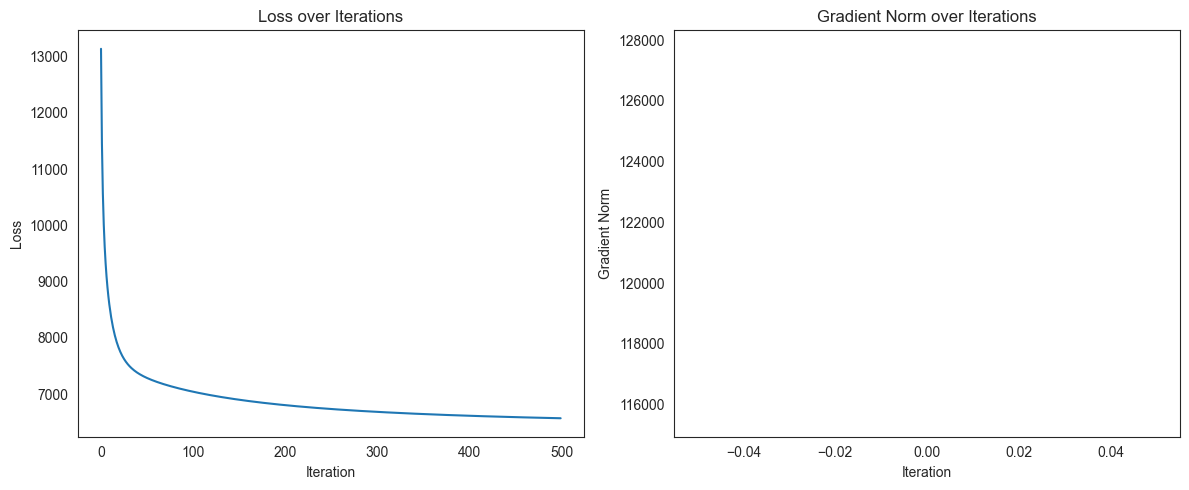

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations")

# Gradient norm plot
plt.subplot(1, 2, 2)
plt.plot(grad_norms)
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm over Iterations")

plt.tight_layout()
plt.show()


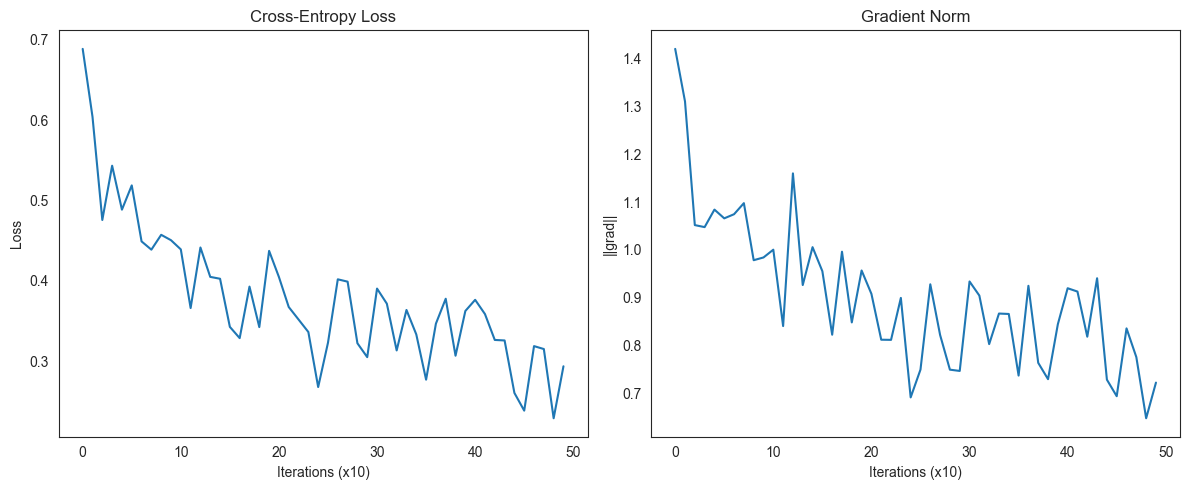

In [ ]:

# 2. Initialize Parameters

A = x_train_final  # Input features (N, 325)
n,m = A.shape
b = Y_train  # One-hot labels (N, 10)
np.random.seed(123)
W = np.zeros((m, 10))  # Weights (replacing your x)
maxiter = 500
batch = 128
vec_loss = []
vec_acc = []
vec_grad_norm = []
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
# 3. SGD Loop
for k in range(1, maxiter + 1):
    # Dynamic learning rate (alpha)
    alpha = 0.1 / np.sqrt(k)
    
    # Random mini-batch selection
    idx = np.random.permutation(n)[:batch]
    A_batch = A[idx]
    b_batch = b[idx]

    # Forward pass: Linear combination + Softmax
    logits = A_batch @ W
    predictions = softmax(logits)

    # Compute Gradient: (A^T * (predictions - targets))
    # This is the classification equivalent of your 2 * A.T @ (Ax - b)
    grad = (1 / batch) * A_batch.T @ (predictions - b_batch)
    grad_norm = la.norm(grad)
    

    # Update weights
    W = W - alpha * grad

    # Track Loss (Cross-Entropy) for plotting
    if k % 10 == 0:
        full_preds = softmax(A[idx] @ W)
        loss = -np.mean(np.sum(b_batch * np.log(full_preds + 1e-8), axis=1))
        vec_loss.append(loss)
        vec_grad_norm.append(grad_norm)

# 4. Visualize Progress
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(vec_loss)
plt.title("Cross-Entropy Loss")
plt.xlabel("Iterations (x10)")
plt.ylabel("Loss")

# Gradient Norm
plt.subplot(1,2,2)
plt.plot(vec_grad_norm)
plt.title("Gradient Norm")
plt.xlabel("Iterations (x10)")
plt.ylabel("||grad||")

plt.tight_layout()
plt.show()

In [ ]:
vec_acc = []
# Track Loss and Accuracy every 10 iterations
if k % 10 == 0:
        # Loss calculation
    loss = -np.mean(np.sum(b_batch * np.log(predictions + 1e-8), axis=1))
    vec_loss.append(loss)
        
    # Accuracy calculation:
    # np.argmax converts [[0, 0, 1...]] -> [2] (the digit label)
    pred_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(b_batch, axis=1)
    accuracy = np.mean(pred_labels == true_labels)
    print(f"Iteration {k}: Accuracy = {accuracy:.4f}")
    vec_acc.append(accuracy)

# 4. Final Accuracy on Test Data
# Assuming you have x_test_final and Y_test (one-hot)
test_logits = x_test_final @ W
test_preds = np.argmax(softmax(test_logits), axis=1)
test_true = np.argmax(Y_test, axis=1)
final_test_acc = np.mean(test_preds == test_true) * 100

print(f"Final Test Accuracy: {final_test_acc:.2f}%")

Iteration 500: Accuracy = 0.9219
Final Test Accuracy: 93.85%


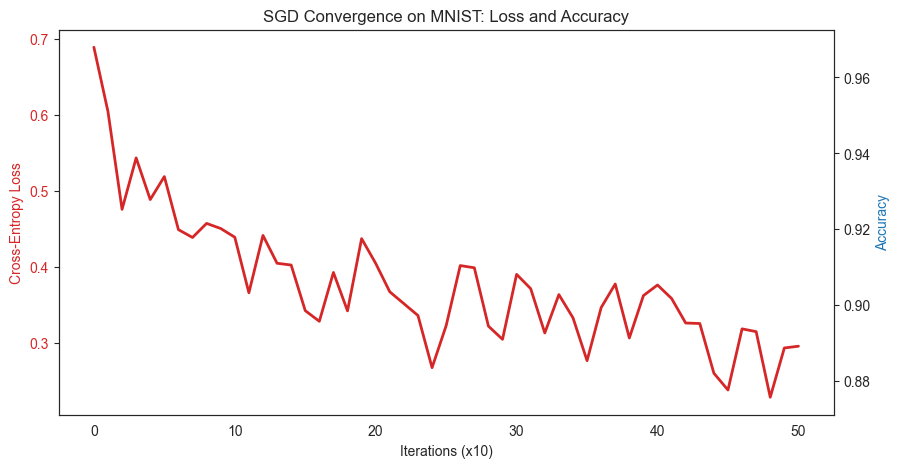

In [ ]:

# Creating a second Y-axis for Accuracy
ax2 = ax1.twinx() 

# 4. Visualize Progress: Loss vs Accuracy
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotting Loss
color_loss = 'tab:red'
ax1.set_xlabel('Iterations (x10)')
ax1.set_ylabel('Cross-Entropy Loss', color=color_loss)
ax1.plot(vec_loss, color=color_loss, label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)

#plot accuracy
ax2 =ax1.twinx()
ax2.plot(vec_acc, color='tab:blue', label='Accuracy (Momentum)', linewidth=2)
ax2.set_ylabel('Accuracy', color='tab:blue')

plt.title("SGD Convergence on MNIST: Loss and Accuracy")
plt.show()


In [ ]:
#Accelerated GD 
# 2. Initialize Parameters
A = x_train_final 
n, m = A.shape
b = Y_train 
np.random.seed(123)

W = np.zeros((m, 10)) 
V = np.zeros((m, 10))  # Velocity vector for momentum
gamma = 0.9            # Momentum coefficient (usually between 0.8 and 0.99)

maxiter = 2000
batch = 300
vec_loss = []
vec_acc = []
vec_grad_norm = []

# 3. Accelerated SGD Loop
for k in range(1, maxiter + 1):
    alpha = 0.1 / np.sqrt(k)
    
    idx = np.random.permutation(n)[:batch]
    A_batch = A[idx]
    b_batch = b[idx]

    # Forward pass
    logits = A_batch @ W
    predictions = softmax(logits)

    # Compute Gradient
    grad = (1 / batch) * A_batch.T @ (predictions - b_batch)
    grad_norm = la.norm(grad)
    # --- ACCELERATION STEP ---
    # 1. Update velocity: V = gamma * V + alpha * grad
    V = gamma * V + alpha * grad
    # 2. Update weights: W = W - V
    W = W - V
    # -------------------------

    if k % 10 == 0:
        # Metrics calculation
        loss = -np.mean(np.sum(b_batch * np.log(predictions + 1e-8), axis=1))
        vec_loss.append(loss)
        print(f"Iteration {k}: Loss = {loss:.4f}")
        vec_grad_norm.append(grad_norm)
        print(f"Iteration {k}: Gradient Norm = {grad_norm:.4e}")
        acc = np.mean(np.argmax(predictions, axis=1) == np.argmax(b_batch, axis=1))
        vec_acc.append(acc)
        print(f"Iteration {k}: Accuracy = {acc:.4f}")

Iteration 10: Loss = 0.4683
Iteration 10: Gradient Norm = 7.1731e-01
Iteration 10: Accuracy = 0.8733
Iteration 20: Loss = 0.5051
Iteration 20: Gradient Norm = 7.1065e-01
Iteration 20: Accuracy = 0.8733
Iteration 30: Loss = 0.3064
Iteration 30: Gradient Norm = 5.1533e-01
Iteration 30: Accuracy = 0.9100
Iteration 40: Loss = 0.3248
Iteration 40: Gradient Norm = 5.0330e-01
Iteration 40: Accuracy = 0.9100
Iteration 50: Loss = 0.3003
Iteration 50: Gradient Norm = 5.1293e-01
Iteration 50: Accuracy = 0.9233
Iteration 60: Loss = 0.2983
Iteration 60: Gradient Norm = 5.2118e-01
Iteration 60: Accuracy = 0.9067
Iteration 70: Loss = 0.2643
Iteration 70: Gradient Norm = 5.2455e-01
Iteration 70: Accuracy = 0.9167
Iteration 80: Loss = 0.3371
Iteration 80: Gradient Norm = 6.1250e-01
Iteration 80: Accuracy = 0.9067
Iteration 90: Loss = 0.3552
Iteration 90: Gradient Norm = 5.3132e-01
Iteration 90: Accuracy = 0.9267
Iteration 100: Loss = 0.2849
Iteration 100: Gradient Norm = 5.1034e-01
Iteration 100: Accur

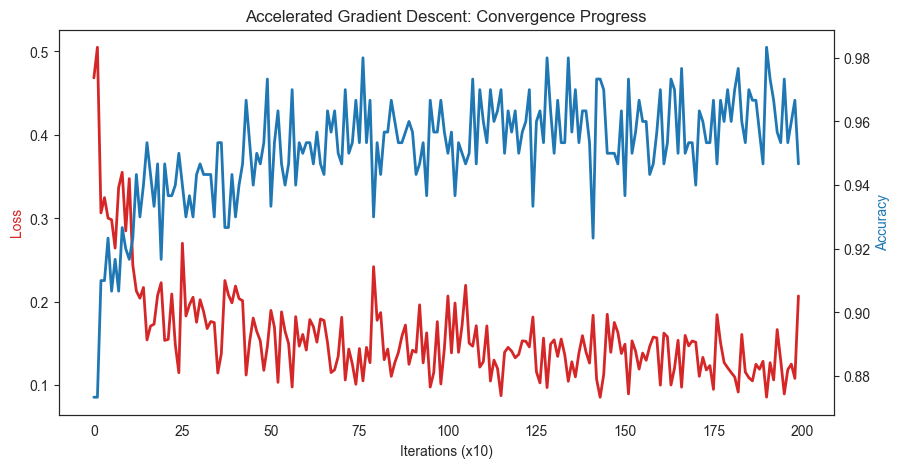

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Loss
ax1.plot(vec_loss, color='tab:red', label='Loss (Momentum)', linewidth=2)
ax1.set_ylabel('Loss', color='tab:red')
ax1.set_xlabel('Iterations (x10)')

# Plot Accuracy
ax2 = ax1.twinx()
ax2.plot(vec_acc, color='tab:blue', label='Accuracy (Momentum)', linewidth=2)
ax2.set_ylabel('Accuracy', color='tab:blue')

plt.title("Accelerated Gradient Descent: Convergence Progress")
plt.show()

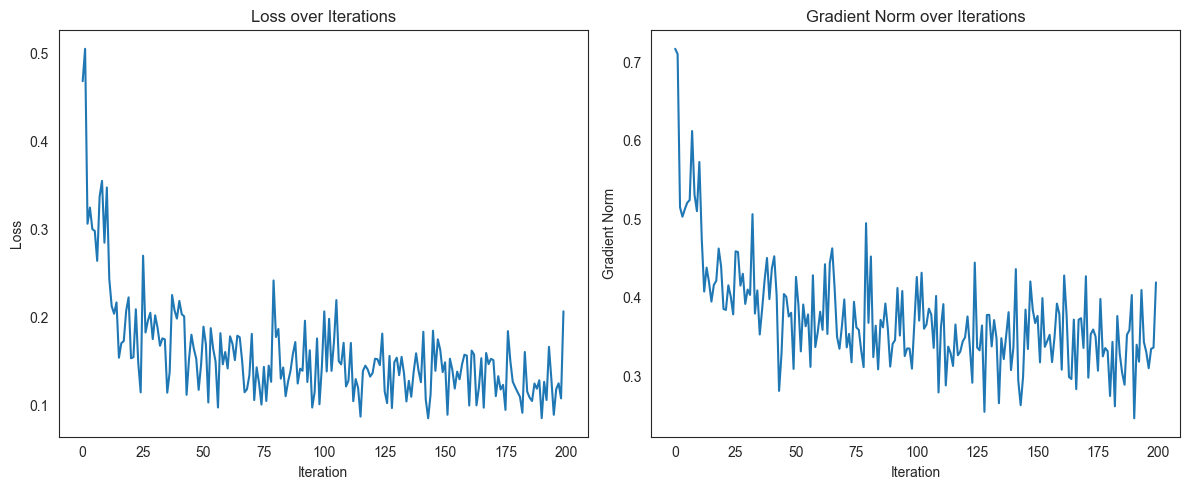

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(vec_loss)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss over Iterations")

# Gradient norm plot
plt.subplot(1, 2, 2)
plt.plot(vec_grad_norm)
plt.xlabel("Iteration")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm over Iterations")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Metrics storage
history = {
    'GD': {'loss': [], 'grad_norm': []},
    'SGD': {'loss': [], 'grad_norm': []},
    'Accel': {'loss': [], 'grad_norm': []}
}

# --- 1. Standard Gradient Descent (MSE) ---
W_gd = np.zeros((x_train_final.shape[1], 10))
L = 2 * la.norm(x_train_final, 2)**2
alpha_gd = 2 / L

for i in range(500):
    grad = 2 * x_train_final.T @ (x_train_final @ W_gd - Y_train)
    W_gd -= alpha_gd * grad
    
    loss = la.norm(x_train_final @ W_gd - Y_train)**2
    history['GD']['loss'].append(loss)
    history['GD']['grad_norm'].append(la.norm(grad))

# --- 2. SGD & Accelerated SGD (Cross-Entropy) ---
methods = ['SGD', 'Accel']
for method in methods:
    W = np.zeros((m, 10))
    V = np.zeros((m, 10))
    gamma = 0.9 if method == 'Accel' else 0.0
    
    for k in range(1, 2001):
        alpha = 0.1 / np.sqrt(k)
        idx = np.random.permutation(n)[:batch]
        
        # Forward & Gradient
        logits = x_train_final[idx] @ W
        predictions = softmax(logits)
        grad = (1 / batch) * x_train_final[idx].T @ (predictions - Y_train[idx])
        
        # Update
        V = gamma * V + alpha * grad
        W = W - V
        
        if k % 10 == 0:
            loss = -np.mean(np.sum(Y_train[idx] * np.log(predictions + 1e-8), axis=1))
            history[method]['loss'].append(loss)
            history[method]['grad_norm'].append(la.norm(grad))

# --- 3. Evaluate Final Test Accuracy ---
def get_acc(W, X, Y):
    preds = np.argmax(X @ W, axis=1)
    true = np.argmax(Y, axis=1)
    return np.mean(preds == true) * 100

print(f"GD Test Accuracy: {get_acc(W_gd, x_test_final, Y_test):.2f}%")

GD Test Accuracy: 93.70%


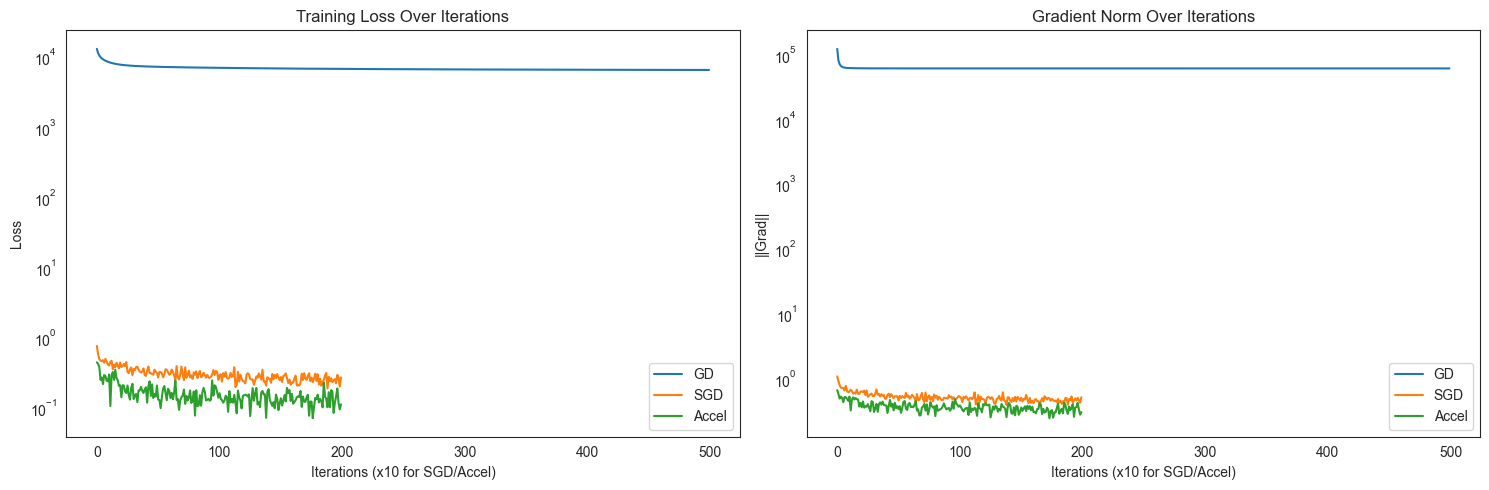

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
for label, data in history.items():
    ax1.plot(data['loss'], label=label)
ax1.set_title("Training Loss Over Iterations")
ax1.set_xlabel("Iterations (x10 for SGD/Accel)")
ax1.set_ylabel("Loss")
ax1.set_yscale('log') # Log scale helps see convergence
ax1.legend()

# Plot Gradient Norm
for label, data in history.items():
    ax2.plot(data['grad_norm'], label=label)
ax2.set_title("Gradient Norm Over Iterations")
ax2.set_xlabel("Iterations (x10 for SGD/Accel)")
ax2.set_ylabel("||Grad||")
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_134 (Dense)               │ (None, 128)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,890 (323.79 KB)

 Trainable params: 82,890 (323.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.0903 - loss: 2.9654
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.1018 - loss: 2.8584
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1138 - loss: 2.7641
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.1275 - loss: 2.6798
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.1428 - loss: 2.6035
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1577 - loss: 2.5337
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.1720 - loss: 2.4695
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1879 - loss: 2.4098
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.2034 - loss: 2.3542
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2200 - loss: 2.3020
GD Training Complete. Evaluating on test set...
GD Test Accuracy: 0.2515
GD Test Loss: 2.1994


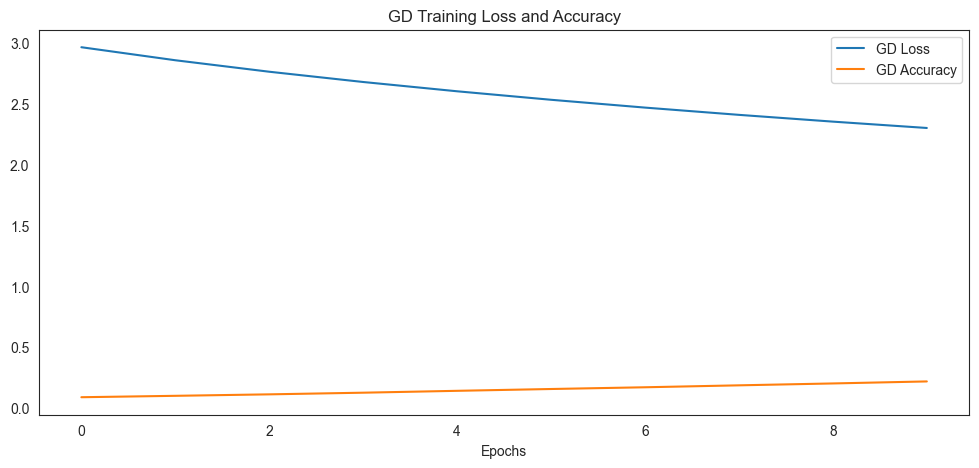

In [ ]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
#To demonstrate different optimizers, we re-compile for each case:
# 1. Implementation for GD (Batch Gradient Descent)
# Use a batch size equal to the entire training set
optimizer_gd = keras.optimizers.SGD(learning_rate=0.01)
model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    
    layers.Dense(128, activation='relu',
                 kernel_initializer='he_uniform',
                 bias_initializer='zeros'),
    
    layers.Dense(64, activation='relu',
                 kernel_initializer='he_uniform',
                 bias_initializer='zeros'),
    
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer=optimizer_gd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Convert One-Hot vectors back to integer labels
Y_train_int = np.argmax(Y_train, axis=1)
model.summary()
history_gd = model.fit(x_train_final, Y_train_int, epochs=10, batch_size=len(x_train_final))
print("GD Training Complete. Evaluating on test set...")
test_loss_gd, test_acc_gd = model.evaluate(x_test_final, np.argmax(Y_test, axis=1), verbose=0)
print(f"GD Test Accuracy: {test_acc_gd:.4f}")
print(f"GD Test Loss: {test_loss_gd:.4f}")
plt.figure(figsize=(12,5))
plt.plot(history_gd.history['loss'], label='GD Loss')
plt.plot(history_gd.history['accuracy'], label='GD Accuracy')
plt.title("GD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()


In [ ]:
# 2. Implementation for SGD (Stochastic Gradient Descent)
# Use a batch size of 1
optimizer_sgd = keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=optimizer_sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Convert One-Hot vectors back to integer labels
Y_train_int = np.argmax(Y_train, axis=1)
model.summary()
history_sgd = model.fit(x_train_final, Y_train_int, epochs=10, batch_size=1)
print("SGD Training Complete. Evaluating on test set...")
test_loss_sgd, test_acc_sgd = model.evaluate(x_test_final, np.argmax(Y_test, axis=1), verbose=0)
print(f"SGD Test Accuracy: {test_acc_sgd:.4f}")
print(f"SGD Test Loss: {test_loss_sgd:.4f}")
plt.figure(figsize=(12,5))
plt.plot(history_sgd.history['loss'], label='SGD Loss')
plt.plot(history_sgd.history['accuracy'], label='SGD Accuracy')
plt.title("SGD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()



Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_134 (Dense)               │ (None, 128)            │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_136 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,890 (323.79 KB)

 Trainable params: 82,890 (323.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - accuracy: 0.9480 - loss: 0.1784
Epoch 2/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - accuracy: 0.9584 - loss: 0.1472
Epoch 3/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 28s 1ms/step - accuracy: 0.9653 - loss: 0.1207
Epoch 4/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - accuracy: 0.9655 - loss: 0.1369
Epoch 5/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 27s 1ms/step - accuracy: 0.9693 - loss: 0.1209
Epoch 6/10
 2391/20000 ━━━━━━━━━━━━━━━━━━━━ 24s 1ms/step - accuracy: 0.9816 - loss: 0.0876

KeyboardInterrupt: 

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9770 - loss: 0.0799
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9883 - loss: 0.0377
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9934 - loss: 0.0202
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9934 - loss: 0.0205
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9868 - loss: 0.0394
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9908 - loss: 0.0280
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9944 - loss: 0.0173
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9973 - loss: 0.0076
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9952 - loss: 0.0147
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9887 - loss: 0.0372
Adam Training Complete. Evaluating on test set...
Adam Test Accuracy: 0.9590
Adam Test Loss: 0.2177


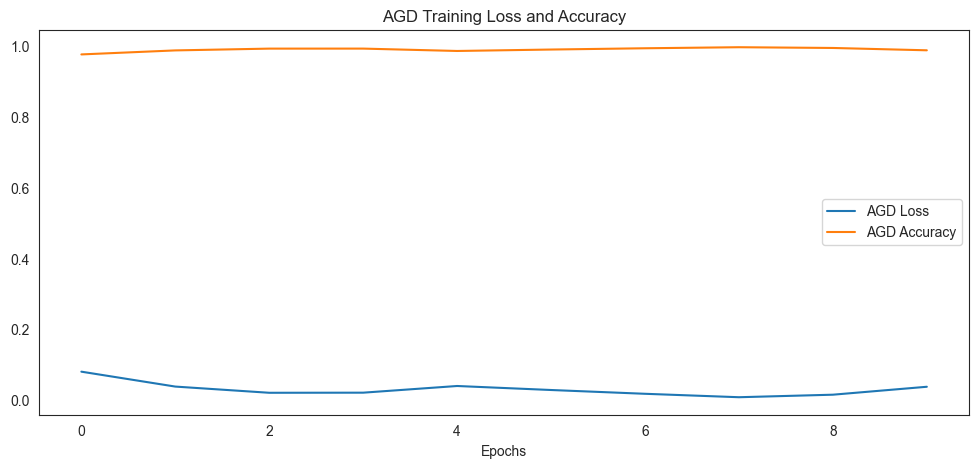

In [ ]:
# 3. Implementation for AGD (Adaptive/Adam)
# This uses adaptive learning rates for each parameter
optimizer_adam = keras.optimizers.Adam(learning_rate=0.001)


model.compile(
    optimizer=optimizer_adam, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history_adam = model.fit(x_train_final, Y_train_int, epochs=10, batch_size=32)
print("Adam Training Complete. Evaluating on test set...")
test_loss_adam, test_acc_adam = model.evaluate(x_test_final, np.argmax(Y_test, axis=1), verbose=0)
print(f"Adam Test Accuracy: {test_acc_adam:.4f}")
print(f"Adam Test Loss: {test_loss_adam:.4f}")

plt.figure(figsize=(12,5))
plt.plot(history_adam.history['loss'], label='AGD Loss')
plt.plot(history_adam.history['accuracy'], label='AGD Accuracy')
plt.title("AGD Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [ ]:
#
#Studying the effect of network depth and width on the training and testing performance.

def build_model(depth, width, activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(num_features,)))
    
    for _ in range(depth):
        model.add(layers.Dense(width, activation=activation))
    
    model.add(layers.Dense(10, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


In [ ]:
#study the effect of depth while keeping width fixed at 64
depths = [1, 2, 3, 4]
fixed_width = 64
depth_results = {}

print("\n===== Depth Experiment =====")

for d in depths:
    print(f"\nTraining Depth = {d}")
    
    model = build_model(depth=d, width=fixed_width, activation='relu')
    
    history = model.fit(
        x_train_final, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(x_test_final, Y_test_int, verbose=0)
    
    depth_results[d] = {
        'history': history.history,
        'test_acc': test_acc
    }
    
    print(f"Depth {d} -> Test Accuracy: {test_acc:.4f}")



===== Depth Experiment =====

Training Depth = 1
Depth 1 -> Test Accuracy: 0.9670

Training Depth = 2
Depth 2 -> Test Accuracy: 0.9565

Training Depth = 3
Depth 3 -> Test Accuracy: 0.9640

Training Depth = 4
Depth 4 -> Test Accuracy: 0.9650


In [ ]:
#study the effect of width while keeping depth fixed at 2
widths = [32, 64, 128, 256]
fixed_depth = 2
width_results = {}

print("\n===== Width Experiment =====")

for w in widths:
    print(f"\nTraining Width = {w}")
    
    model = build_model(depth=fixed_depth, width=w, activation='relu')
    
    history = model.fit(
        x_train_final, Y_train_int,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(x_test_final, Y_test_int, verbose=0)
    
    width_results[w] = {
        'history': history.history,
        'test_acc': test_acc
    }
    
    print(f"Width {w} -> Test Accuracy: {test_acc:.4f}")



===== Width Experiment =====

Training Width = 32
Width 32 -> Test Accuracy: 0.9605

Training Width = 64
Width 64 -> Test Accuracy: 0.9635

Training Width = 128
Width 128 -> Test Accuracy: 0.9710

Training Width = 256
Width 256 -> Test Accuracy: 0.9690


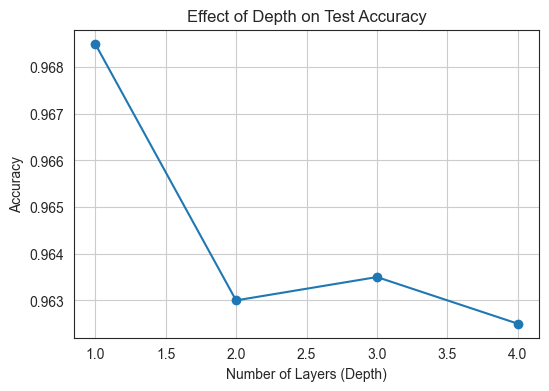

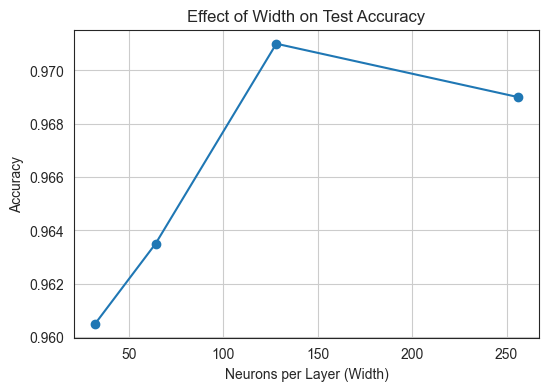

In [ ]:
#depth plot

plt.figure(figsize=(6,4))
plt.plot(depths, [depth_results[d]['test_acc'] for d in depths], marker='o')
plt.title("Effect of Depth on Test Accuracy")
plt.xlabel("Number of Layers (Depth)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()
#width plot
plt.figure(figsize=(6,4))
plt.plot(widths, [width_results[w]['test_acc'] for w in widths], marker='o')
plt.title("Effect of Width on Test Accuracy")
plt.xlabel("Neurons per Layer (Width)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [ ]:
model = build_model(depth=2, width=64, activation='relu')
history, test_acc, test_loss = train_model('relu')
print(f"ReLU -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")
model = build_model(depth=2, width=64, activation='sigmoid')
history, test_acc, test_loss = train_model('sigmoid')   
print(f"Sigmoid -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")  
model = build_model(depth=2, width=64, activation='tanh')
history, test_acc, test_loss = train_model('tanh')
print(f"Tanh -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9072 - loss: 0.2978 - val_accuracy: 0.9165 - val_loss: 0.2479
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9716 - loss: 0.0881 - val_accuracy: 0.9215 - val_loss: 0.2518
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0458 - val_accuracy: 0.9185 - val_loss: 0.2759
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9901 - loss: 0.0291 - val_accuracy: 0.9375 - val_loss: 0.2267
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9943 - loss: 0.0186 - val_accuracy: 0.9350 - val_loss: 0.2612
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9909 - loss: 0.0271 - val_accuracy: 0.9225 - val_loss: 0.3325
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9899 - loss: 0.0289 - val_accuracy: 0.9255 - val_loss: 0.3386
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()
nb_model.fit(x_train_final, Y_train_int)
y_pred_nb = nb_model.predict(x_test_final)
acc_nb = accuracy_score(Y_test_int, y_pred_nb)

print("Naive Bayes Accuracy:", acc_nb)


Naive Bayes Accuracy: 0.788


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(x_train_final, Y_train_int)

y_pred_rf = rf_model.predict(x_test_final)
acc_rf = accuracy_score(Y_test_int, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)


Random Forest Accuracy: 0.954


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

gb_model.fit(x_train_final, Y_train_int)

y_pred_gb = gb_model.predict(x_test_final)
acc_gb = accuracy_score(Y_test_int, y_pred_gb)

print("Gradient Boosting Accuracy:", acc_gb)


In [ ]:
pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 5.7 MB/s eta 0:00:18
    --------------------------------------- 2.4/101.7 MB 5.5 MB/s eta 0:00:18
   - -------------------------------------- 3.7/101.7 MB 5.8 MB/s eta 0:00:17
   - -------------------------------------- 4.7/101.7 MB 5.7 MB/s eta 0:00:17
   -- ------------------------------------- 5.8/101.7 MB 5.6 MB/s eta 0:00:18
   -- ------------------------------------- 7.1/101.7 MB 5.6 MB/s eta 0:00:17
   --- ------------------------------------ 8.1/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 9.4/101.7 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.5/101.7 MB 5.7 MB/s eta 0:00:17
   ---- ----------------------------------- 12.1/101.7 MB 5.8 MB/s eta 0:00:1

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(x_train_final, Y_train_int)

y_pred_xgb = xgb_model.predict(x_test_final)
acc_xgb = accuracy_score(Y_test_int, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
import matplotlib.pyplot as plt

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()
